# Advanced Phishing Email Detection: Naive Bayes + DistilBERT
This notebook compares two approaches for classifying emails into **Ham**, **Spam**, or **Phishing** using **7 data sources** (~560k emails):
- **Naive Bayes + TF-IDF** as a fast baseline model with engineered phishing features
- **DistilBERT** as a deep learning model that understands context

Labels: **0** = Ham (legitimate), **1** = Spam (unwanted), **2** = Phishing (malicious/fraudulent)

In [31]:
# Core libraries for data handling, plotting, and text preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
import os
import time
import json
import joblib
# Machine learning tools for the Naive Bayes baseline
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

## 1. Load and Normalize All 7 Datasets
We combine multiple sources to train a robust 3-class classifier:
- **0** = Ham (legitimate email)
- **1** = Spam (general unwanted email)
- **2** = Phishing (malicious/fraudulent email)

In [32]:
DATA_DIR = '../Dataset'

def load_existing():
    df = pd.read_csv(os.path.join(DATA_DIR, 'spam_Emails_data.csv'), encoding='latin-1')
    df['label_num'] = df['label'].map({'Ham': 0, 'Spam': 1})
    df['source'] = 'existing'
    return df[['text', 'label_num', 'source']].copy()

def load_enron():
    df = pd.read_csv(os.path.join(DATA_DIR, 'enron_spam.csv'))
    df['label_num'] = df['label'].map({0: 0, 1: 1})
    df['source'] = 'enron'
    return df[['text', 'label_num', 'source']].copy()

def load_spamassassin():
    df = pd.read_csv(os.path.join(DATA_DIR, 'spamassassin.csv'))
    df['label_num'] = df['label'].map({0: 0, 1: 1})
    df.rename(columns={'data': 'text'}, inplace=True)
    df['source'] = 'spamassassin'
    return df[['text', 'label_num', 'source']].copy()

def load_phishing_liu():
    df = pd.read_csv(os.path.join(DATA_DIR, 'phishing_liu.csv'))
    df['label_num'] = df['Email Type'].map({'Safe Email': 0, 'Phishing Email': 2})
    df.rename(columns={'Email Text': 'text'}, inplace=True)
    df['source'] = 'phishing_liu'
    return df[['text', 'label_num', 'source']].copy()

def load_phishing_7ds():
    df = pd.read_csv(os.path.join(DATA_DIR, 'phishing_7ds.csv'))
    df['label_num'] = df['label'].map({0: 0, 1: 1})
    df['source'] = 'phishing_7ds'
    return df[['text', 'label_num', 'source']].copy()

def load_phishing_v2():
    df = pd.read_csv(os.path.join(DATA_DIR, 'phishing_v2.csv'))
    # 0=benign(ham), 1=spam, 2=phishing, 3=malware -> treat malware as phishing
    df['label_num'] = df['label'].map({0: 0, 1: 1, 2: 2, 3: 2})
    df.rename(columns={'content': 'text'}, inplace=True)
    df['source'] = 'phishing_v2'
    return df[['text', 'label_num', 'source']].copy()

def load_phishing_rbn():
    df = pd.read_csv(os.path.join(DATA_DIR, 'phishing_rbn.csv'))
    df['label_num'] = df['email_type'].map({'safe email': 0, 'phishing email': 2})
    df['source'] = 'phishing_rbn'
    return df[['text', 'label_num', 'source']].copy()

In [33]:
# Load all datasets and display their sizes and label distributions
loaders = [
    ('Existing (193k)', load_existing),
    ('Enron', load_enron),
    ('SpamAssassin', load_spamassassin),
    ('Phishing Liu', load_phishing_liu),
    ('Phishing 7DS', load_phishing_7ds),
    ('Phishing v2.0', load_phishing_v2),
    ('Phishing Rabin', load_phishing_rbn),
]

all_dfs = []
for name, loader in loaders:
    df = loader()
    dist = dict(df['label_num'].value_counts().sort_index())
    print(f'{name:22s} -> {len(df):>6d} rows, labels: {dist}')
    all_dfs.append(df)

combined = pd.concat(all_dfs, ignore_index=True)
print(f'\nTOTAL: {len(combined):,} rows')
print(f'Label distribution: {dict(combined["label_num"].value_counts().sort_index())}')

Existing (193k)        -> 193852 rows, labels: {0: np.int64(102160), 1: np.int64(91692)}
Enron                  ->  31716 rows, labels: {0: np.int64(15553), 1: np.int64(16163)}
SpamAssassin           ->   6046 rows, labels: {0: np.int64(4150), 1: np.int64(1896)}
Phishing Liu           ->  18650 rows, labels: {0: np.int64(11322), 2: np.int64(7328)}
Phishing 7DS           -> 162413 rows, labels: {0: np.int64(86951), 1: np.int64(75462)}
Phishing v2.0          -> 120000 rows, labels: {0: np.int64(6809), 1: np.int64(6684), 2: np.int64(106507)}
Phishing Rabin         ->  26946 rows, labels: {0: np.int64(13473), 2: np.int64(13473)}

TOTAL: 559,623 rows
Label distribution: {0: np.int64(240418), 1: np.int64(191897), 2: np.int64(127308)}


In [34]:
# Drop any rows with missing text
before = len(combined)
combined = combined.dropna(subset=['text']).reset_index(drop=True)
print('Dropped', before - len(combined), 'rows with missing text')
print('Final dataset shape:', combined.shape)

combined.head()

Dropped 72 rows with missing text
Final dataset shape: (559551, 3)


,text,label_num,source
0,viiiiiiagraaaa\nonly for the ones that want to...,1,existing
1,got ice thought look az original message ice o...,0,existing
2,yo ur wom an ne eds an escapenumber in ch ma n...,1,existing
3,start increasing your odds of success & live s...,1,existing
4,author jra date escapenumber escapenumber esca...,0,existing


## 2. Text Preprocessing
Clean the email text by removing HTML, links, emails, non-alphabetic characters, and standardizing whitespace.

In [35]:
# Clean the raw email text for the Naive Bayes model
# This removes HTML tags, links, emails, numbers, punctuation, stop words, and abnormally long tokens
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' emailtoken ', text)
    text = re.sub(r'\d+', ' numbertoken ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [word for word in text.split() if word not in ENGLISH_STOP_WORDS and len(word) <= 50]
    return ' '.join(tokens)

print('Cleaning email text...')
t0 = time.time()
combined['clean_text'] = combined['text'].apply(clean_text)
print(f'Cleaned {len(combined):,} texts in {time.time()-t0:.1f}s')

Cleaning email text...
Cleaned 559,551 texts in 131.2s


In [36]:
# Show sample cleaned text
combined[['label_num', 'text', 'clean_text']].head()

,label_num,text,clean_text
0,1,viiiiiiagraaaa\nonly for the ones that want to...,viiiiiiagraaaa ones want make scream prodigy s...
1,0,got ice thought look az original message ice o...,got ice thought look az original message ice o...
2,1,yo ur wom an ne eds an escapenumber in ch ma n...,yo ur wom ne eds escapenumber ch ma n b e th m...
3,1,start increasing your odds of success & live s...,start increasing odds success live sexually he...
4,0,author jra date escapenumber escapenumber esca...,author jra date escapenumber escapenumber esca...


### Rule-Based Phishing Features
Extract phishing-specific signals that help distinguish phishing from regular spam, such as brand impersonation, urgency language, typosquatting, and suspicious URL patterns.

In [37]:
# Build a simple phishing score from several warning signs instead of one keyword only
urgent_patterns = [
    r'urgent', r'immediately', r'action required', r'account suspended',
    r'verify your account', r'confirm your identity', r'limited time'
]

sensitive_patterns = [
    r'password', r'otp', r'login', r'bank account',
    r'credit card', r'ssn', r'social security'
]

brand_patterns = [
    r'paypal', r'microsoft', r'google', r'apple',
    r'bank', r'netflix', r'amazon'
]

THREAT_WORDS = ['terminated', 'charged', 'fee', 'penalty', 'legal action', 'lawsuit']
CREDENTIAL_PHRASES = ['verify your password', 'confirm your account', 'login details',
                      'update your billing', 'your account has been']
SUSPICIOUS_DOMAIN_PATTERNS = ['secure-', 'account-', 'verify-', 'login-', 'update-', 'confirm-']

def extract_all_features(text):
    """Extract structural and phishing-specific features from raw email text."""
    text = str(text) if not isinstance(text, str) else text
    clean_lower = text.lower()
    words = clean_lower.split()
    urls = re.findall(r'http[s]?://\S+', text)
    
    return {
        'text_length': len(text),
        'word_count': len(words),
        'avg_word_length': np.mean([len(w) for w in words]) if words else 0,
        'capital_ratio': sum(1 for c in text if c.isupper()) / max(len(text), 1),
        'url_count': len(urls),
        'exclamation_count': text.count('!'),
        'question_count': text.count('?'),
        'dollar_count': text.count('$'),
        'has_free': 1 if 'free' in clean_lower else 0,
        'has_urgent': 1 if any(re.search(p, clean_lower) for p in urgent_patterns) else 0,
        'brand_count': sum(clean_lower.count(b) for b in ['paypal', 'amazon', 'netflix', 'apple', 'google', 'microsoft', 'facebook']),
        'urgency_score': sum(1 for p in urgent_patterns if re.search(p, clean_lower)),
        'threat_score': sum(1 for w in THREAT_WORDS if w in clean_lower),
        'credential_request': sum(1 for p in CREDENTIAL_PHRASES if p in clean_lower),
        'typosquatting': len(re.findall(r'payp[a0]l|g00gle|faceb00k|micr0s0ft', clean_lower)),
        'suspicious_urls': sum(
            1 for u in urls
            for pat in SUSPICIOUS_DOMAIN_PATTERNS if pat in u.lower()
        ),
    }

print('Extracting features...')
t0 = time.time()
feature_dicts = combined['text'].apply(extract_all_features)
feature_df = pd.DataFrame(feature_dicts.tolist())
combined = pd.concat([combined, feature_df], axis=1)
print(f'Extracted {len(feature_df.columns)} features in {time.time()-t0:.1f}s')
print('Features:', list(feature_df.columns))

Extracting features...
Extracted 16 features in 102.9s
Features: ['text_length', 'word_count', 'avg_word_length', 'capital_ratio', 'url_count', 'exclamation_count', 'question_count', 'dollar_count', 'has_free', 'has_urgent', 'brand_count', 'urgency_score', 'threat_score', 'credential_request', 'typosquatting', 'suspicious_urls']


In [38]:
# Show average feature values per class to see what distinguishes phishing from spam
combined.groupby('label_num')[list(feature_df.columns)].mean().round(2)

,text_length,word_count,avg_word_length,capital_ratio,url_count,exclamation_count,question_count,dollar_count,has_free,has_urgent,brand_count,urgency_score,threat_score,credential_request,typosquatting,suspicious_urls
label_num,,,,,,,,,,,,,,,,
0,2232.75,359.79,5.34,0.02,0.68,0.65,1.11,0.84,0.12,0.04,0.13,0.04,0.13,0.0,0.00,0.0
1,1352.29,204.77,6.57,0.03,0.59,1.08,0.95,0.96,0.15,0.05,0.16,0.06,0.15,0.0,0.02,0.0
2,185.85,26.64,31.69,0.01,0.95,0.27,0.44,0.14,0.02,0.01,0.03,0.01,0.01,0.0,0.00,0.0


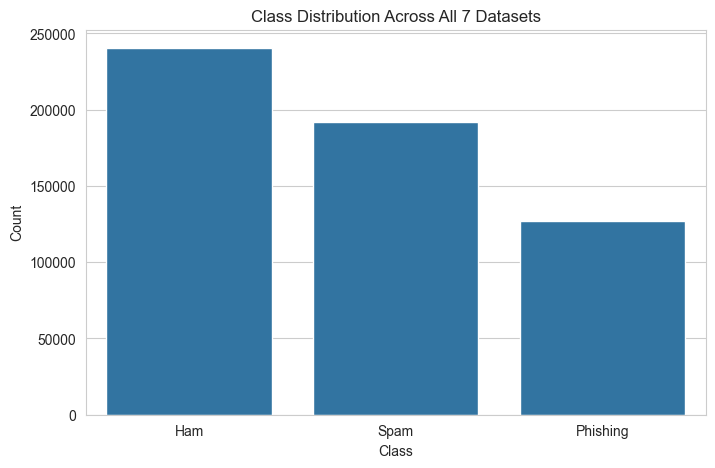

In [39]:
# Plot the class distribution
label_names = {0: 'Ham', 1: 'Spam', 2: 'Phishing'}
combined['label_name'] = combined['label_num'].map(label_names)
plt.figure(figsize=(8, 5))
sns.countplot(x='label_name', data=combined, order=['Ham', 'Spam', 'Phishing'])
plt.title('Class Distribution Across All 7 Datasets')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

## 3. Train/Test Split
We split the data before training so we can test the model on unseen emails. stratify=y keeps the class ratio similar in both sets.

In [40]:
# Use the cleaned text for the Naive Bayes baseline
# Split the data into training and testing sets
FEATURE_COLS = [c for c in feature_df.columns]
X_text = combined['clean_text']
y = combined['label_num']
X_feat = combined[FEATURE_COLS].values.astype(np.float32)

X_train_text, X_test_text, y_train, y_test, X_train_feat, X_test_feat = train_test_split(
    X_text, y, X_feat,
    test_size=0.2,
    random_state=42,
    stratify=y
)

dist_train = {int(k): int(v) for k, v in zip(*np.unique(y_train, return_counts=True))}
dist_test = {int(k): int(v) for k, v in zip(*np.unique(y_test, return_counts=True))}
print('Training samples:', len(X_train_text), ' distribution:', dist_train)
print('Testing samples:', len(X_test_text), '  distribution:', dist_test)

Training samples: 447640  distribution: {0: 192333, 1: 153473, 2: 101834}
Testing samples: 111911   distribution: {0: 48084, 1: 38369, 2: 25458}


## 4. Naive Bayes Model
This baseline uses **TF-IDF** to turn text into numeric features and **Multinomial Naive Bayes** to classify each email into ham, spam, or phishing.

In [41]:
TRAIN_NAIVE_BAYES = True
# Set to False after first training to load saved model

In [42]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# Train a new Naive Bayes model or load a saved one
if TRAIN_NAIVE_BAYES:
    # Convert text into TF-IDF features using single words and short phrases
    print('Training TF-IDF vectorizer...')
    t0 = time.time()
    tfidf = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )
    X_train_tfidf = tfidf.fit_transform(X_train_text)
    X_test_tfidf = tfidf.transform(X_test_text)
    print(f'  TF-IDF done: {X_train_tfidf.shape} in {time.time()-t0:.1f}s')
    
    # Scale engineered features and concatenate with TF-IDF
    print('Scaling engineered features...')
    scaler = MinMaxScaler()
    X_train_feat_scaled = scaler.fit_transform(X_train_feat)
    X_test_feat_scaled = scaler.transform(X_test_feat)
    X_train_combined = hstack([X_train_tfidf, X_train_feat_scaled])
    X_test_combined = hstack([X_test_tfidf, X_test_feat_scaled])
    print(f'  Combined shape: {X_train_combined.shape}')
    
    # Class weights to penalize misclassifying the minority phishing class more
    class_counts = np.bincount(y_train.astype(int))
    class_weights = {i: len(y_train) / (len(class_counts) * count) for i, count in enumerate(class_counts)}
    print(f'  Class weights: {class_weights}')
    sample_weights = np.array([class_weights[y] for y in y_train])
    
    # Train the classifier on the combined features
    nb_model = MultinomialNB(alpha=0.5)
    nb_model.fit(X_train_combined, y_train, sample_weight=sample_weights)
    
    # Save the trained model, vectorizer, and scaler for later reuse
    joblib.dump(nb_model, '../naive_bayes_3class_model.pkl')
    joblib.dump(tfidf, '../tfidf_vectorizer_3class.pkl')
    joblib.dump(scaler, '../feature_scaler_3class.pkl')
    print('Naive Bayes model trained and saved.')
else:
    # Load the model, vectorizer, and scaler from disk
    nb_model = joblib.load('../naive_bayes_3class_model.pkl')
    tfidf = joblib.load('../tfidf_vectorizer_3class.pkl')
    scaler = joblib.load('../feature_scaler_3class.pkl')
    # Transform the test set using the saved TF-IDF vocabulary and scaler
    X_test_tfidf = tfidf.transform(X_test_text)
    X_test_feat_scaled = scaler.transform(X_test_feat)
    X_test_combined = hstack([X_test_tfidf, X_test_feat_scaled])
    print('Saved Naive Bayes model loaded successfully.')

Training TF-IDF vectorizer...
  TF-IDF done: (447640, 5469917) in 171.7s
Scaling engineered features...
  Combined shape: (447640, 5469933)
  Class weights: {0: np.float64(0.7758072371009308), 1: np.float64(0.9722448465419542), 2: np.float64(1.4652604565600225)}
Naive Bayes model trained and saved.


In [43]:
# Predict labels on the test set using combined TF-IDF + engineered features
nb_preds = nb_model.predict(X_test_combined)

In [44]:
# Evaluate the Naive Bayes model using standard classification metrics
nb_accuracy = accuracy_score(y_test, nb_preds)
print('Naive Bayes Accuracy:', round(nb_accuracy, 4))
print(classification_report(y_test, nb_preds, target_names=['ham', 'spam', 'phishing']))

Naive Bayes Accuracy: 0.97
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99     48084
        spam       0.95      0.96      0.96     38369
    phishing       0.98      0.94      0.96     25458

    accuracy                           0.97    111911
   macro avg       0.97      0.96      0.97    111911
weighted avg       0.97      0.97      0.97    111911



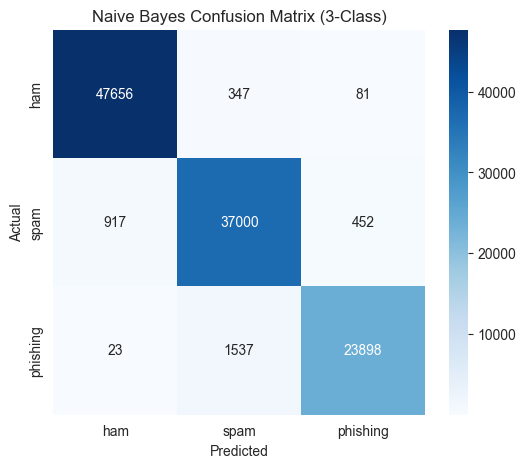

In [45]:
# Plot the confusion matrix to see correct and incorrect classifications
cm_nb = confusion_matrix(y_test, nb_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham', 'spam', 'phishing'],
            yticklabels=['ham', 'spam', 'phishing'])
plt.title('Naive Bayes Confusion Matrix (3-Class)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [46]:
# Calculate and display False Positive Rate per class
print('False Positive Rate per class:')
print('=' * 35)
for i, name in enumerate(['Ham', 'Spam', 'Phishing']):
    fp = cm_nb[:, i].sum() - cm_nb[i, i]
    tn = cm_nb.sum() - (cm_nb[i, :].sum() + cm_nb[:, i].sum() - cm_nb[i, i])
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    print(f'{name:15s} FPR: {fpr*100:.2f}%')

False Positive Rate per class:
Ham             FPR: 1.47%
Spam            FPR: 2.56%
Phishing        FPR: 0.62%


## 5. DistilBERT Model
DistilBERT is a smaller and faster version of BERT. It uses the original email text and a tokenizer to convert the text into token IDs and attention masks before training.

**Note:** DistilBERT is trained on a subsample of the full dataset since it is computationally expensive on CPU.

### DistilBERT Data Preparation
We use a smaller sample because DistilBERT is heavier than Naive Bayes, especially on CPU.

In [47]:
# DistilBERT uses the original text column, not clean_text
# Using 100k samples since CUDA is available
BERT_SAMPLE_SIZE = 100000
BERT_MAX_LENGTH = 128
TRAIN_DISTILBERT = True
DISTILBERT_MODEL_DIR = './distilbert_3class_model'
bert_df = combined.sample(n=min(BERT_SAMPLE_SIZE, len(combined)), random_state=42)
X_bert = bert_df['text']
y_bert = bert_df['label_num']
X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(
    X_bert,
    y_bert,
    test_size=0.2,
    random_state=42,
    stratify=y_bert
)
print('DistilBERT dataset size:', len(bert_df))
print('DistilBERT training samples:', len(X_train_bert))
print('DistilBERT testing samples:', len(X_test_bert))
print('\nLabel distribution in DistilBERT sample:')
print(y_bert.value_counts().sort_index())

DistilBERT dataset size: 100000
DistilBERT training samples: 80000
DistilBERT testing samples: 20000

Label distribution in DistilBERT sample:
label_num
0    43064
1    34207
2    22729
Name: count, dtype: int64


### DistilBERT Libraries and Device Check
This step imports the Hugging Face tools and checks whether the notebook will use a GPU or CPU.

In [48]:
# Import the libraries needed for DistilBERT fine-tuning
# Disable tokenizer parallelism to keep notebook output cleaner
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import precision_recall_fscore_support
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

Device: cuda


### Tokenization Process
Tokenization converts each raw email into numbers that DistilBERT can understand. The tokenizer also pads short emails, truncates long ones, and creates attention masks so the model knows which positions contain real text.

In [49]:
# Load the tokenizer that matches distilbert-base-uncased
model_name = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)
print('Tokenizer loaded successfully!')

Tokenizer loaded successfully!


In [50]:
# Convert the train and test text into Hugging Face Dataset objects
train_dataset = Dataset.from_dict({
    'text': X_train_bert.tolist(),
    'label': y_train_bert.tolist()
})
test_dataset = Dataset.from_dict({
    'text': X_test_bert.tolist(),
    'label': y_test_bert.tolist()
})
print(train_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 80000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 20000
})


In [51]:
# Tokenize each email into input_ids and attention_mask
# max_length=128 keeps the sequence length manageable on CPU
def tokenize_function(example):
    return tokenizer(
        example['text'],
        truncation=True,
        padding='max_length',
        max_length=BERT_MAX_LENGTH
    )
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)
# Remove the raw text and switch the datasets to PyTorch format
train_dataset = train_dataset.remove_columns(['text'])
test_dataset = test_dataset.remove_columns(['text'])
train_dataset.set_format('torch')
test_dataset.set_format('torch')
print(train_dataset[0].keys())
print('Input length:', len(train_dataset[0]['input_ids']))

Map: 100%|██████████| 20000/20000 [00:20<00:00, 953.82 examples/s] 

dict_keys(['label', 'input_ids', 'token_type_ids', 'attention_mask'])
Input length: 128


In [52]:
# Load the pre-trained DistilBERT model with a 3-class classification head
print('Loading DistilBERT model for sequence classification...')
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)
print('Model loaded successfully!')

Loading DistilBERT model for sequence classification...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2786.28it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully!


In [53]:
# Compute evaluation metrics from DistilBERT predictions
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average='weighted',
        zero_division=0
    )
    acc = accuracy_score(labels, predictions)
    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [54]:
# Configure the DistilBERT fine-tuning process
training_args = TrainingArguments(
    output_dir='./results_3class',
    eval_strategy='epoch',
    save_strategy='epoch',
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=100,
    logging_dir='./logs_3class',
    logging_steps=500,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    report_to='none'
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [55]:
# Create the Hugging Face Trainer that manages training, evaluation, and logging
print('Creating Trainer...')
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)
print('Trainer created!')

Creating Trainer...
Trainer created!


In [56]:
# Train a new DistilBERT model or load a saved one from disk
if TRAIN_DISTILBERT:
    print('Starting DistilBERT training (this may take a few minutes on CPU)...')
    trainer.train()
    trainer.save_model(DISTILBERT_MODEL_DIR)
    tokenizer.save_pretrained(DISTILBERT_MODEL_DIR)
    print('Training completed and model saved!')
else:
    print('Skipping training. Loading saved DistilBERT model...')
    model = AutoModelForSequenceClassification.from_pretrained(DISTILBERT_MODEL_DIR)
    tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_MODEL_DIR)
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics
    )
    print('Saved DistilBERT model loaded successfully!')

Starting DistilBERT training (this may take a few minutes on CPU)...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.099557,0.123857,0.970550,0.971603,0.970550,0.970646
2,0.075801,0.110956,0.973400,0.974097,0.973400,0.973415


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.83it/s]

Training completed and model saved!


In [57]:
# Predict labels and probabilities for the DistilBERT test set
pred_output = trainer.predict(test_dataset)
bert_logits = pred_output.predictions
bert_preds = np.argmax(bert_logits, axis=1)
# Calculate the main evaluation metrics
bert_accuracy = accuracy_score(y_test_bert, bert_preds)
print('DistilBERT Accuracy:', round(bert_accuracy, 4))
print(classification_report(y_test_bert, bert_preds, target_names=['ham', 'spam', 'phishing']))

DistilBERT Accuracy: 0.9734
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99      8613
        spam       0.94      0.98      0.96      6841
    phishing       1.00      0.94      0.97      4546

    accuracy                           0.97     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.97      0.97      0.97     20000



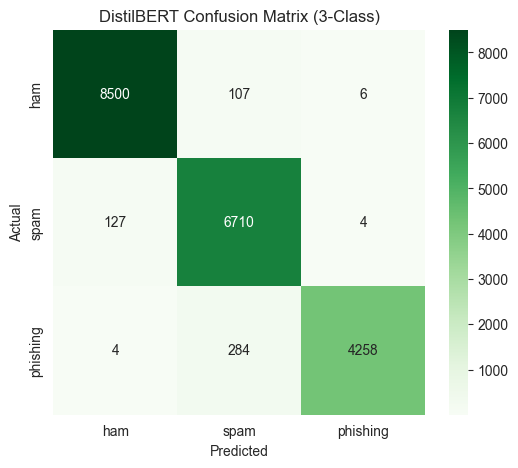

In [58]:
# Plot the DistilBERT confusion matrix
cm_bert = confusion_matrix(y_test_bert, bert_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Greens',
            xticklabels=['ham', 'spam', 'phishing'],
            yticklabels=['ham', 'spam', 'phishing'])
plt.title('DistilBERT Confusion Matrix (3-Class)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 6. Model Comparison
Compare the Naive Bayes and DistilBERT models side by side.

In [59]:
# Put both model results into one table for easy comparison
nb_precision = precision_score(y_test, nb_preds, average='weighted')
nb_recall = recall_score(y_test, nb_preds, average='weighted')
nb_f1 = f1_score(y_test, nb_preds, average='weighted')

bert_precision = precision_score(y_test_bert, bert_preds, average='weighted')
bert_recall = recall_score(y_test_bert, bert_preds, average='weighted')
bert_f1 = f1_score(y_test_bert, bert_preds, average='weighted')

comparison_df = pd.DataFrame({
    'Model': ['Naive Bayes', 'DistilBERT'],
    'Accuracy': [round(nb_accuracy, 4), round(bert_accuracy, 4)],
    'Precision (weighted)': [round(nb_precision, 4), round(bert_precision, 4)],
    'Recall (weighted)': [round(nb_recall, 4), round(bert_recall, 4)],
    'F1-score (weighted)': [round(nb_f1, 4), round(bert_f1, 4)],
    'Training Data': [f'{len(X_train_text):,} samples', f'{len(X_train_bert)} samples']
})
comparison_df

,Model,Accuracy,Precision (weighted),Recall (weighted),F1-score (weighted),Training Data
0,Naive Bayes,0.9700,0.9701,0.9700,0.9699,"447,640 samples"
1,DistilBERT,0.9734,0.9741,0.9734,0.9734,80000 samples


### DistilBERT vs Naive Bayes
- **Naive Bayes** is faster and trained on the full 560k dataset, so it usually gets higher accuracy.
- **DistilBERT** is slower but understands context better because it uses tokenization and pre-trained language knowledge.
- Naive Bayes with engineered features is often the more practical model for large-scale phishing detection.
- DistilBERT can be improved with more training data and more epochs if GPU resources are available.

## 7. Save Results
Save the evaluation results for both models and the combined dataset for later reference.

In [60]:
# Save evaluation results to JSON
results = {
    'models': {
        'Naive Bayes': {
            'accuracy': round(nb_accuracy, 4),
            'precision_weighted': round(nb_precision, 4),
            'recall_weighted': round(nb_recall, 4),
            'f1_weighted': round(nb_f1, 4),
            'confusion_matrix': cm_nb.tolist()
        },
        'DistilBERT': {
            'accuracy': round(bert_accuracy, 4),
            'precision_weighted': round(bert_precision, 4),
            'recall_weighted': round(bert_recall, 4),
            'f1_weighted': round(bert_f1, 4),
            'confusion_matrix': cm_bert.tolist()
        }
    },
    'total_samples': len(combined),
    'label_distribution': {0: int((y == 0).sum()), 1: int((y == 1).sum()), 2: int((y == 2).sum())},
    'feature_count': len(FEATURE_COLS),
    'distilbert_sample_size': BERT_SAMPLE_SIZE
}

with open('../3class_comparison_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('Results saved to ../3class_comparison_results.json')
print('\nPipeline complete!')

Results saved to ../3class_comparison_results.json

Pipeline complete!
